# **1. Winsorization**

Caps extreme values at a chosen percentile instead of removing them. Limits outlier impact while keeping all rows.

Use when

-> Financial data (capping extreme returns)

-> Sensor / IoT readings

-> Survey responses with extreme values

-> When removing outliers is not allowed

Avoid when

Not appropriate when outliers are genuinely meaningful signals

**Solution 1 :- Using Limits**

In [ ]:
from scipy.stats.mstats import winsorize
import pandas as pd

In [ ]:
df = pd.DataFrame({
    'Salary': [20000, 25000, 30000, 35000, 40000, 50000, 500000]
})

In [ ]:
df['Salary_Winsor'] = winsorize(df['Salary'], limits = [0.15, 0.15])

In [ ]:
print(df)

   Salary  Salary_Winsor
0   20000          25000
1   25000          25000
2   30000          30000
3   35000          35000
4   40000          40000
5   50000          50000
6  500000          50000


**Solution 2 :- Using clip()**

In [ ]:
df = pd.DataFrame({
    'Salary': [20000, 25000, 30000, 35000, 40000, 50000, 500000]
})

In [ ]:
lower = df['Salary'].quantile(0.05)
upper = df['Salary'].quantile(0.95)

In [ ]:
df['Salary_Winsor'] = df['Salary'].clip(lower, upper)

/tmp/ipykernel_5731/4287786718.py:1: FutureWarning: Downcasting behavior in Series and DataFrame methods 'where', 'mask', and 'clip' is deprecated. In a future version this will not infer object dtypes or cast all-round floats to integers. Instead call result.infer_objects(copy=False) for object inference, or cast round floats explicitly. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Salary_Winsor'] = df['Salary'].clip(lower, upper)


In [ ]:
print(df)

   Salary  Salary_Winsor
0   20000          21500
1   25000          25000
2   30000          30000
3   35000          35000
4   40000          40000
5   50000          50000
6  500000         365000


# **2. Z-Score Outlier Removal**

Identifies and removes points more than 3 standard deviations from mean. Assumes normally distributed data.

Use when

-> Normally distributed features

-> Quick data cleaning

-> Lab / scientific measurements

Avoid when

Unreliable on skewed data — transform first, then apply Z-score.

In [ ]:
from scipy.stats import zscore
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
df = pd.DataFrame({
    'Salary': [20000, 25000, 30000, 35000, 40000, 50000, 500000]
})

In [ ]:
df['z_score'] = zscore(df['Salary'])

In [ ]:
mean = df['Salary'].mean()
std = df['Salary'].std()

In [ ]:
upper = mean + 3 * std
lower = mean - 3 * std

In [ ]:
df['Salary'] = np.where(
    df['Salary'] > upper, upper, df['Salary']
)

In [ ]:
df['Salary'] = np.where(
    df['Salary'] < lower, lower, df['Salary']
)

In [ ]:
df['z_score']

,z_score
0,-0.489134
1,-0.458563
2,-0.427992
3,-0.397422
4,-0.366851
5,-0.305709
6,2.445671


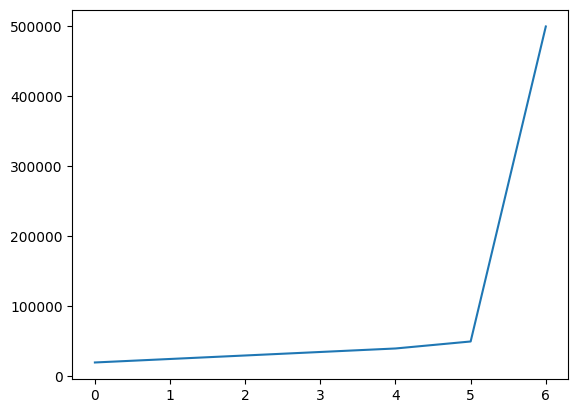

In [ ]:
plt.plot(df['Salary'])
plt.show()

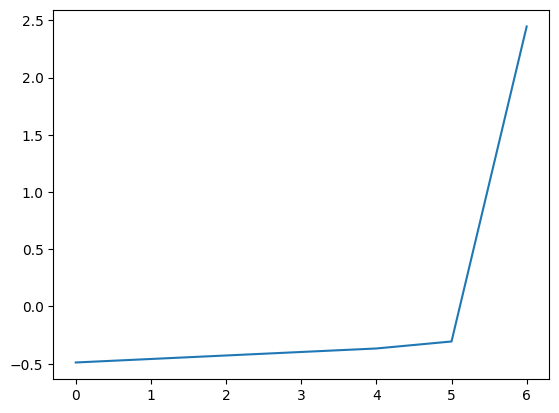

In [ ]:
plt.plot(df['z_score'])
plt.show()

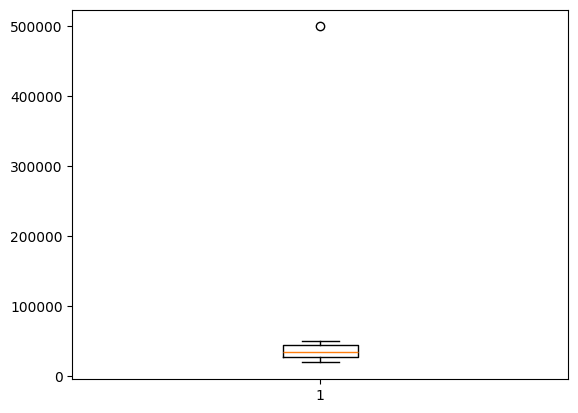

In [ ]:
plt.boxplot(df['Salary'])
plt.show()

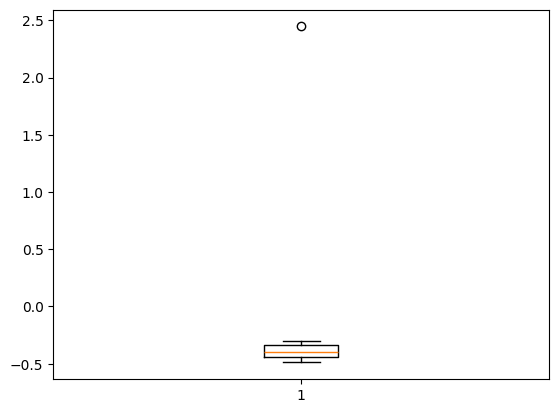

In [ ]:
plt.boxplot(df['z_score'])
plt.show()

# **3. Inter Quertile Range(IQR)**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df = pd.DataFrame({
    'Salary': [20000, 25000, 30000, 35000, 40000, 50000, 500000]
})

In [ ]:
Q1 = df['Salary'].quantile(0.25)
Q3 = df['Salary'].quantile(0.75)

In [ ]:
IQR = Q3 - Q1

In [ ]:
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

In [ ]:
df['Salary'] = df['Salary'].clip(lower, upper)

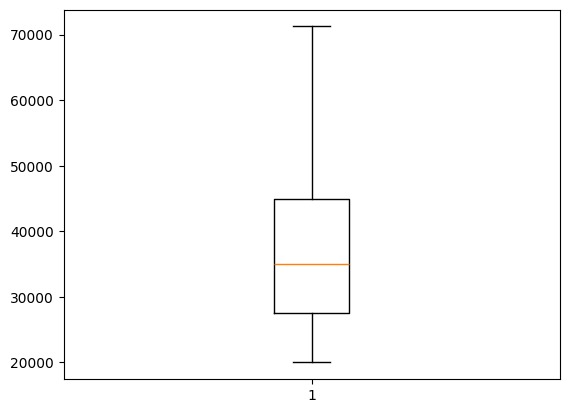

In [ ]:
plt.boxplot(df['Salary'])
plt.show()

In [ ]:
df.describe()

,Salary
count,7.000000
mean,38750.000000
std,17395.521454
min,20000.000000
25%,27500.000000
50%,35000.000000
75%,45000.000000
max,71250.000000


In [ ]:
df

,Salary
0,20000
1,25000
2,30000
3,35000
4,40000
5,50000
6,71250
